# **FingerVein dataset exploration (MMCBNU_6000)**


# **Preliminary operations**
The lab notebooks fetch their data on the fly (e.g. `!wget ...` in *DL_01: Regression*).
This project instead uses **non-public, provisional archives** that we keep **locally** and
**out of version control** (`*.zip` and `proj_files/` are git-ignored). There is therefore
nothing to download here.

Before running the notebook, place the dataset archives under `proj_files/` at the
repository root:

```
proj_files/
├── MMCBNU_6000.zip                                            ← FingerVein
└── brno-university-of-technology-...-but-ppg-2.0.0.zip        ← PPG
```

We read the data **directly from the `.zip`** (decoding each `.bmp` in memory), so the archives do not need to be
extracted.


# **Useful module imports**
As in the labs, we first import every module used in the notebook, then fix a single
documented random seed for the reproducible image sampling done later.

We read everything straight from the archive: `zipfile` opens the `.zip`, `io` + `PIL.Image`
decode each `.bmp` into a NumPy array, and `pypdf` reads the per-subject demographics table
from the description PDF bundled inside the archive.


In [1]:
import io
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pypdf import PdfReader

# Reproducibility: one documented seed (see AGENTS.md, "Scientific constraints").
SEED = 0
random.seed(SEED)
np.random.seed(SEED)

# **Datasets**
This notebook explores the **FingerVein** modality: the **MMCBNU_6000** near-infrared
finger-vein image database.

| Property | Value |
|---|---|
| Unit of observation | one finger-vein image (`.bmp`) |
| Structure | 100 subjects × 6 fingers × 10 captures = **6000 images** (ROIs) |
| Image | 8-bit grayscale (exact shape printed in *Dataset overview* below) |
| Target (project) | subject **age** in years (regression) |

> **Two image trees.** The archive actually holds **12000** `.bmp` files: 6000 raw frames under
> `Captured images/` **and** 6000 vein-region crops under `ROIs/`. We use the **ROIs** (the
> standard model input), so `list_images` returns 6000, one per (subject, finger, capture).

**About the labels (important).** MMCBNU_6000 was released for finger-vein *recognition*,
not age estimation, but the bundled `Description of MMCBNU_6000.pdf` contains an
**Information table** with each subject's **age, gender, nationality and blood type**. We
parse `age` and `gender` from that PDF (see *Subject demographics* below) and use them as
**provisional labels**.

> ⚠️ **Provenance & caveats.** These labels are (a) extracted from a PDF table, so they
> depend on the text extraction being correct, and (b) from a *provisional public* dataset,
> not the non-public datasets named in the proposal (`proposta-rivista.md`). They are fine
> for exploration, but any finding must be reported as **exploratory** until the official
> data are available.

The cell below locates the archive under `proj_files/` and reads it in place (no extraction).

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'proj_files'
FV_ZIP = DATA_DIR / 'MMCBNU_6000.zip'

assert FV_ZIP.exists(), f'FingerVein archive not found: {FV_ZIP} (see "Preliminary operations")'
print('Repository root :', PROJECT_ROOT)
print('FingerVein zip  :', FV_ZIP.name, f'({FV_ZIP.stat().st_size / 1e6:.0f} MB)')

Repository root : /Users/muni/Documents/uni/DL/PPG_FingerVein_age_detection
FingerVein zip  : MMCBNU_6000.zip (677 MB)


# **Utility functions**
- **list_images** returns the list of `.bmp` entries inside the archive;
- **parse_path** extracts `(subject, finger, capture)` from an image path;
- **load_image** reads one `.bmp` from the archive into a NumPy array.

In [3]:
def list_images(zip_path):
    # MMCBNU_6000 ships two parallel trees: 'Captured images/' (raw) and 'ROIs/' (vein-region
    # crops). We use the ROIs - they are the standard finger-vein model input - so there is
    # exactly one image per (subject, finger, capture): 100 x 6 x 10 = 6000.
    with zipfile.ZipFile(zip_path) as z:
        return sorted(n for n in z.namelist()
                      if n.lower().endswith('.bmp') and '/ROIs/' in n)


def parse_path(name):
    # .../ROIs/<subject>/<finger>/<capture>.bmp
    parts = name.split('/')
    subject = parts[-3]
    finger = parts[-2]
    capture = parts[-1].replace('.bmp', '')
    return subject, finger, capture


def load_image(zip_path, name):
    with zipfile.ZipFile(zip_path) as z:
        return np.array(Image.open(io.BytesIO(z.read(name))))

# **Dataset overview**
Let's count images, subjects and fingers, and check a single image's shape.

In [4]:
images = list_images(FV_ZIP)
meta = [parse_path(n) for n in images]

subjects = sorted({m[0] for m in meta})
fingers = sorted({m[1] for m in meta})

print(f'Total images : {len(images)}')
print(f'Subjects     : {len(subjects)}  (e.g. {subjects[:5]} ...)')
print(f'Fingers      : {len(fingers)} -> {fingers}')

sample = load_image(FV_ZIP, images[0])
print(f'Image shape  : {sample.shape}  dtype={sample.dtype}  '
      f'min={sample.min()} max={sample.max()}')

Total images : 6000
Subjects     : 100  (e.g. ['001', '002', '003', '004', '005'] ...)
Fingers      : 6 -> ['L_Fore', 'L_Middle', 'L_Ring', 'R_Fore', 'R_Middle', 'R_Ring']
Image shape  : (60, 128)  dtype=uint8  min=85 max=212


# **Subject demographics (the labels)**
Unlike a PhysioNet record, MMCBNU_6000 ships **no `subject-info.csv`**. The per-subject demographics live in `Description of MMCBNU_6000.pdf`, which contains an *Information table* of the 100 volunteers with columns **Order, Age, Nationality, Gender, Blood type**.

We read that PDF straight from the archive (no extraction) and parse the table into a DataFrame. `Order` (1..100) maps one-to-one onto the image subject folders `001..100`, and **`Age` is our regression target**.

In [5]:
def load_subject_info(zip_path):
    """Parse the 100-row 'Information table' from the description PDF inside the archive."""
    with zipfile.ZipFile(zip_path) as z:
        pdf_name = next(n for n in z.namelist() if n.lower().endswith('.pdf'))
        reader = PdfReader(io.BytesIO(z.read(pdf_name)))
    text = '\n'.join((page.extract_text() or '') for page in reader.pages)

    rows = []
    for line in text.splitlines():
        toks = line.split()
        # a data row starts with: <order:int> <age:int> ...
        if len(toks) >= 4 and toks[0].isdigit() and toks[1].isdigit():
            gi = next((i for i, t in enumerate(toks[2:], 2) if t in ('M', 'F')), None)
            if gi is None:
                continue
            rows.append({
                'Order': int(toks[0]),
                'Subject': f'{int(toks[0]):03d}',          # matches the image folders
                'Age': int(toks[1]),
                'Nationality': ' '.join(toks[2:gi]),
                'Gender': toks[gi],
                'Blood type': ' '.join(toks[gi + 1:]) or None,
            })
    return pd.DataFrame(rows).sort_values('Order').reset_index(drop=True)


info = load_subject_info(FV_ZIP)
print('subjects:', len(info))
info.head()

subjects: 100


,Order,Subject,Age,Nationality,Gender,Blood type
0,1,001,22,China,F,B
1,2,002,24,China,M,AB
2,3,003,22,China,M,O
3,4,004,27,Afghanistan,M,A
4,5,005,47,China,M,NaN


# **Age and gender distribution**
Same target-distribution check as the PPG notebook. The age range is narrow (mostly twenties, a few older outliers), which will matter for the age-regression error analysis.

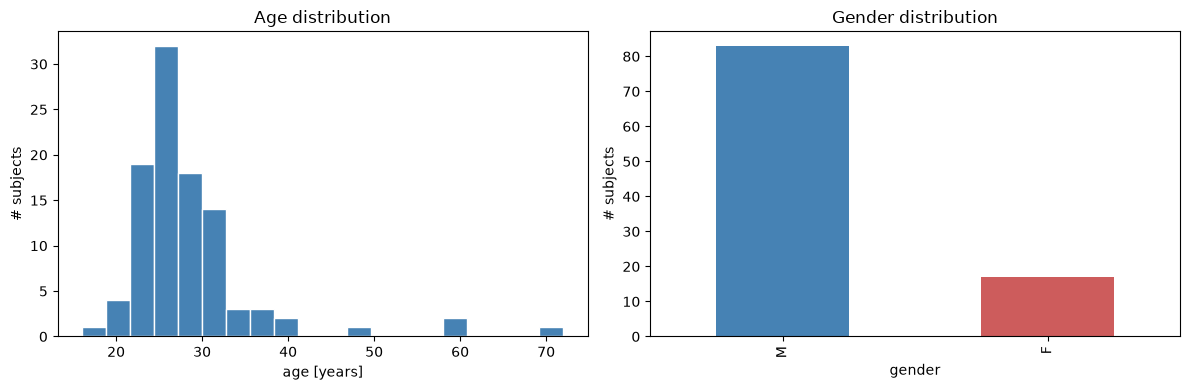

count    100.0
mean      28.4
std        7.7
min       16.0
25%       25.0
50%       27.0
75%       30.0
max       72.0
Name: Age, dtype: float64


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(info['Age'], bins=20, color='steelblue', edgecolor='white')
ax1.set_title('Age distribution')
ax1.set_xlabel('age [years]')
ax1.set_ylabel('# subjects')

info['Gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Gender distribution')
ax2.set_xlabel('gender')
ax2.set_ylabel('# subjects')
plt.tight_layout()
plt.show()

print(info['Age'].describe().round(1))

# **A grid of finger-vein images**
We display the 6 fingers of a single subject to appreciate the vein patterns.

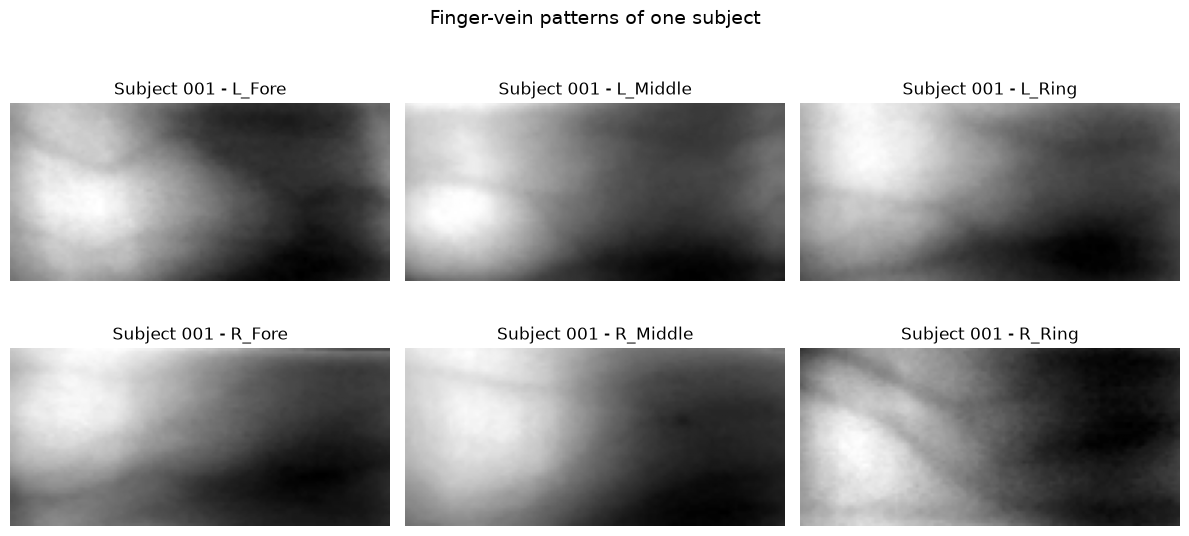

In [7]:
subject = subjects[0]
subject_imgs = [n for n in images if parse_path(n)[0] == subject]
# one image per finger
first_per_finger = {}
for n in subject_imgs:
    f = parse_path(n)[1]
    first_per_finger.setdefault(f, n)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (finger, name) in zip(axes.ravel(), sorted(first_per_finger.items())):
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subject} - {finger}')
    ax.axis('off')
fig.suptitle('Finger-vein patterns of one subject', fontsize=14)
plt.tight_layout()
plt.show()

# **Same finger across different subjects**
Inter-subject variability of the vein pattern (this is what makes the modality biometric).

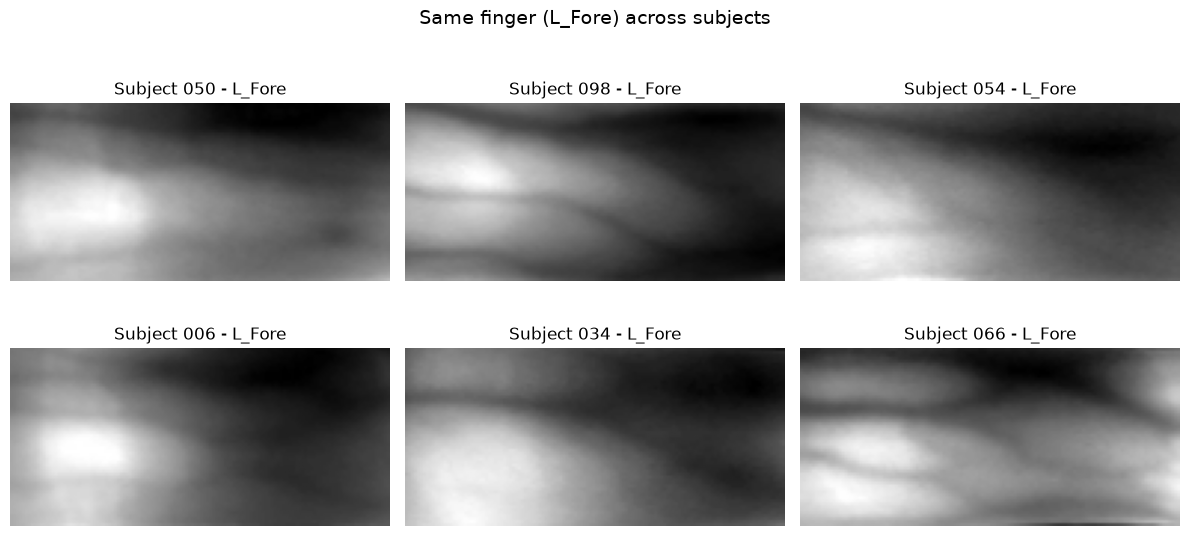

In [8]:
finger = fingers[0]
chosen = random.sample(subjects, 6)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, subj in zip(axes.ravel(), chosen):
    name = next(n for n in images if parse_path(n)[:2] == (subj, finger))
    ax.imshow(load_image(FV_ZIP, name), cmap='gray')
    ax.set_title(f'Subject {subj} - {finger}')
    ax.axis('off')
fig.suptitle(f'Same finger ({finger}) across subjects', fontsize=14)
plt.tight_layout()
plt.show()

# **Pixel intensity distribution**
Understanding the illumination/contrast of the raw images helps design the preprocessing (ROI extraction, contrast normalization) described in the proposal.

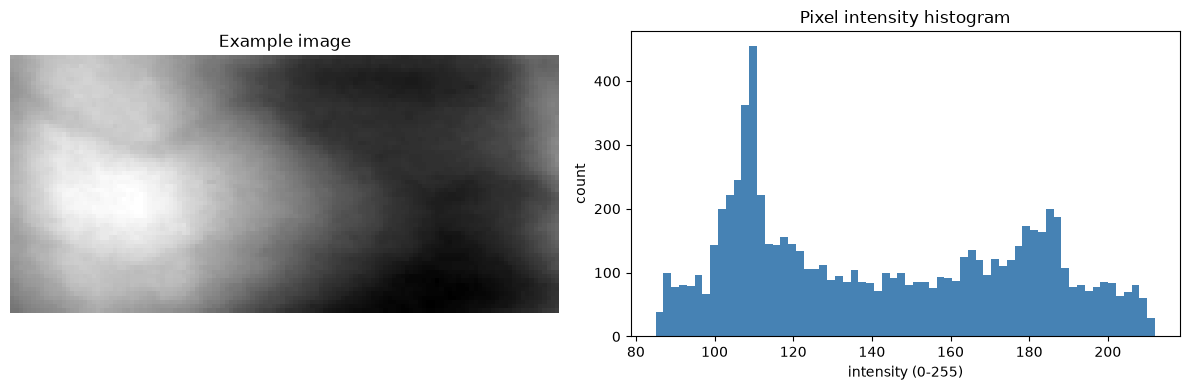

In [9]:
img = load_image(FV_ZIP, images[0])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray')
ax1.set_title('Example image')
ax1.axis('off')
ax2.hist(img.ravel(), bins=64, color='steelblue')
ax2.set_title('Pixel intensity histogram')
ax2.set_xlabel('intensity (0-255)')
ax2.set_ylabel('count')
plt.tight_layout()
plt.show()